Dataset: (1000, 10)
Features: ['Credit_Score', 'Income', 'Debt_Ratio', 'Loan_Amount', 'Employment', 'Age', 'History', 'Accounts', 'Inquiries', 'Balance']

Testing different n_estimators:
n=10: Test Acc=0.890, OOB Score=0.879
n=50: Test Acc=0.907, OOB Score=0.910


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


n=100: Test Acc=0.890, OOB Score=0.907
n=200: Test Acc=0.893, OOB Score=0.911
n=500: Test Acc=0.893, OOB Score=0.926

Feature Importance Ranking:
1. Credit_Score: 0.258
2. Debt_Ratio: 0.192
3. Loan_Amount: 0.098
4. Income: 0.086
5. Inquiries: 0.073
6. History: 0.071
7. Age: 0.066
8. Balance: 0.065
9. Employment: 0.063
10. Accounts: 0.028

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       135
           1       0.95      0.85      0.90       165

    accuracy                           0.89       300
   macro avg       0.89      0.90      0.89       300
weighted avg       0.90      0.89      0.89       300



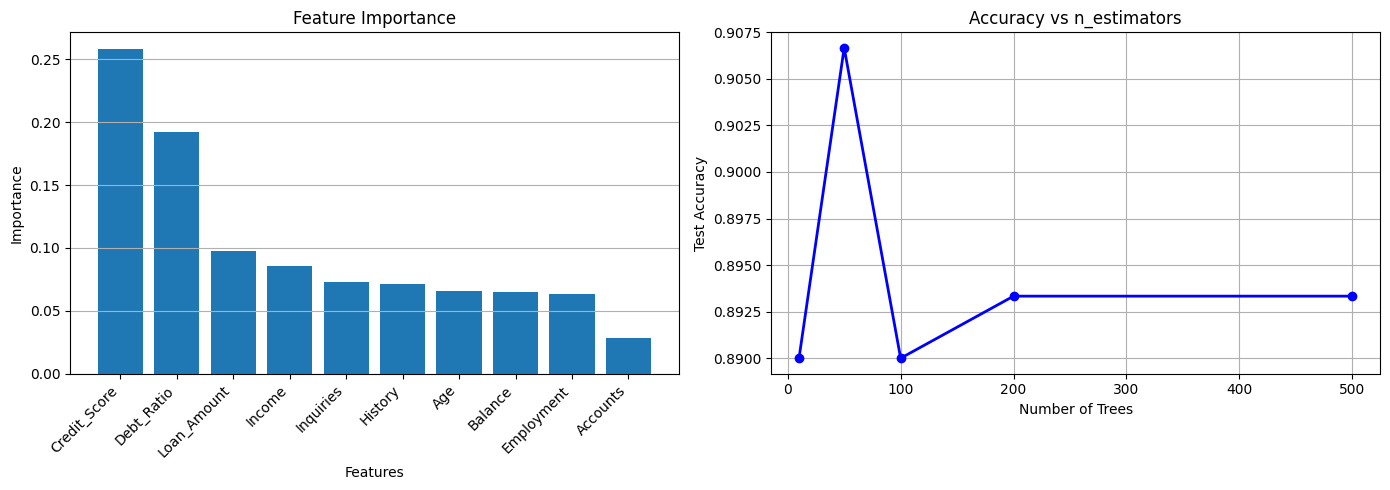

In [1]:
"""
Assignment 7: Random Forest
Feature Importance and OOB Error
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import classification_report

# Generate loan default dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=7,
                           n_classes=2, random_state=42)

feature_names = ['Credit_Score', 'Income', 'Debt_Ratio', 'Loan_Amount',
                'Employment', 'Age', 'History', 'Accounts', 'Inquiries', 'Balance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Dataset:", X.shape)
print("Features:", feature_names)

# Test different n_estimators
n_estimators_list = [10, 50, 100, 200, 500]
accuracies = []

print("\nTesting different n_estimators:")
for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, oob_score=True)
    rf.fit(X_train, y_train)
    acc = rf.score(X_test, y_test)
    accuracies.append(acc)
    print(f"n={n}: Test Acc={acc:.3f}, OOB Score={rf.oob_score_:.3f}")

# Train final model
rf_final = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42)
rf_final.fit(X_train, y_train)

# Feature importance
importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nFeature Importance Ranking:")
for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.3f}")

# Predictions
y_pred = rf_final.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance plot
ax1.bar(range(10), importances[indices])
ax1.set_xticks(range(10))
ax1.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')
ax1.set_xlabel('Features')
ax1.set_ylabel('Importance')
ax1.set_title('Feature Importance')
ax1.grid(True, axis='y')

# n_estimators vs accuracy
ax2.plot(n_estimators_list, accuracies, 'bo-', linewidth=2)
ax2.set_xlabel('Number of Trees')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('Accuracy vs n_estimators')
ax2.grid(True)

plt.tight_layout()
plt.savefig('assignment7_rf.png')
